<a href="https://colab.research.google.com/github/sitiirma-data/data-manipulation-python/blob/main/sales_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Supermarket Sales Analysis

## Objective
Analyze sales data to understand customer behavior and business performance.

## Tools
- Python (Pandas, NumPy)
- Data Manipulation
- Feature Engineering

In [ ]:
# --- Data Manipulation ----
import pandas as pd
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

#--- Numerical Computation ----
import numpy as np

In [ ]:
df_supermarket = pd.read_csv('https://drive.google.com/uc?id=1T9i9yV1NE45r9ZepJXDcx52b2WGKLJcg')

In [ ]:
df_supermarket.head(3)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4


In [ ]:
# memahami data yang dimiliki sebelum melakukan manipulasi data
# data understanding
df_supermarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

Berdasarkan jenis tipe data tersebut secara keseluruhan sudah sesuai, kecuali pada kolom Date karena masih berupa Object. Kolom Date akan diubah menjadi tipe data datetime64. Sedangkan untuk kolom time yang juga berupa object dapat diubah juga menjadi int64 untuk mengambil waktu pagi, siang, sore dan malam

In [ ]:
df_supermarket['Date'] = pd.to_datetime(df_supermarket['Date'])
df_supermarket['Time'] = pd.to_datetime(df_supermarket['Time'])

/tmp/ipykernel_598/2008187011.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_supermarket['Time'] = pd.to_datetime(df_supermarket['Time'])


In [ ]:
df_supermarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   datetime64[ns]
 12  Payment                  1000 non-n

# Data Filtering

In [ ]:
#Mengekstrak data spesifik berdasarkan kondisi tertentu
df_supermarket.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,2026-03-06 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,2026-03-06 10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,2026-03-06 13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,2026-03-06 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,2026-03-06 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


Cek value counts berdasarkan pertanyaan analisa

In [ ]:
df_supermarket['Branch'].value_counts()

,count
Branch,
A,340
B,332
C,328


In [ ]:
df_supermarket['Gender'].value_counts()

,count
Gender,
Female,501
Male,499


In [ ]:
df_supermarket['Product line'].value_counts()

,count
Product line,
Fashion accessories,178
Food and beverages,174
Electronic accessories,170
Sports and travel,166
Home and lifestyle,160
Health and beauty,152


In [ ]:
df_supermarket['Payment'].value_counts()

,count
Payment,
Ewallet,345
Cash,344
Credit card,311


In [ ]:
# Filtering di cabang A
df_a = df_supermarket[df_supermarket['Branch']== 'A']
df_a.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,2026-03-06 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,2026-03-06 13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,2026-03-06 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,2026-03-06 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3
6,355-53-5943,A,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2019-02-25,2026-03-06 14:36:00,Ewallet,413.04,4.761905,20.6520,5.8


Filtering dilakukan untuk menampilkan transaksi yang terjadi di cabang A. Hasil filtering ini menghasilkan subset data di Cabang A untuk keperluan analisis lebih lanjut di cabang tersebut.

In [ ]:
# Filtering berdasarkan konsumen wanita
df_female = df_supermarket.loc[df_supermarket.Gender== 'Female']
df_female.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,2026-03-06 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,2026-03-06 10:29:00,Cash,76.40,4.761905,3.8200,9.6
6,355-53-5943,A,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2019-02-25,2026-03-06 14:36:00,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2019-02-24,2026-03-06 11:38:00,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,A,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.1460,2019-01-10,2026-03-06 17:15:00,Credit card,72.52,4.761905,3.6260,7.2


Filtering dilakukan untuk menampilkan transaksi yang dilakukan oleh pelanggan wanita untuk membandingkan pola pembelian antar pelanggan wanita pada analisa selanjutnya.

In [ ]:
# Filtering berdasarkan konsumen wanita yang menggunakan metode pembayaran e-wallet
df_b =df_supermarket[
                      (df_supermarket['Gender'] == 'Female') &
                      (df_supermarket['Payment'] == 'Ewallet')
      ]

df_b.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,2026-03-06 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
6,355-53-5943,A,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2019-02-25,2026-03-06 14:36:00,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2019-02-24,2026-03-06 11:38:00,Ewallet,735.60,4.761905,36.7800,8.0
10,351-62-0822,B,Mandalay,Member,Female,Fashion accessories,14.48,4,2.8960,60.8160,2019-02-06,2026-03-06 18:07:00,Ewallet,57.92,4.761905,2.8960,4.5
12,365-64-0515,A,Yangon,Normal,Female,Electronic accessories,46.95,5,11.7375,246.4875,2019-02-12,2026-03-06 10:25:00,Ewallet,234.75,4.761905,11.7375,7.1


Filtering dilakukan untuk menampilkan transaksi yang dilakukan oleh pelanggan wanita yang menggunakan pembayaran e-wallet sebagai preferensi metode pembayaran pada pelanggan wanita.

In [ ]:
# Filtering berdasarkan pembayaran dengan cash atau penjualan (transaksi) yang lebih dari 500
df_c = df_supermarket[
          (df_supermarket['Payment'] == 'Cash') |
          (df_supermarket['Total'] > 500)
            ]
df_c.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,2026-03-06 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,2026-03-06 10:29:00,Cash,76.40,4.761905,3.8200,9.6
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,2026-03-06 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,7,29.8865,627.6165,2019-03-25,2026-03-06 18:30:00,Ewallet,597.73,4.761905,29.8865,4.1
7,315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2019-02-24,2026-03-06 11:38:00,Ewallet,735.60,4.761905,36.7800,8.0


Filtering dilakukan untuk menampilkan transaksi yang menggunakan metode pembayaran cash atau transaksi dengan total pembelian lebih dari 500. Tujuannya untuk melihat transaksi dengan metode pembayaran tertentu atau transaksi bernilai besar.

# Data Sorting

In [ ]:
# Penjualan tertinggi
penjualan_tertinggi = df_supermarket.sort_values(by='Total', ascending=False)
penjualan_tertinggi.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
350,860-79-0874,C,Naypyitaw,Member,Female,Fashion accessories,99.30,10,49.65,1042.65,2019-02-15,2026-03-06 14:53:00,Credit card,993.0,4.761905,49.65,6.6
167,687-47-8271,A,Yangon,Normal,Male,Fashion accessories,98.98,10,49.49,1039.29,2019-02-08,2026-03-06 16:20:00,Credit card,989.8,4.761905,49.49,8.7
557,283-26-5248,C,Naypyitaw,Member,Female,Food and beverages,98.52,10,49.26,1034.46,2019-01-30,2026-03-06 20:23:00,Ewallet,985.2,4.761905,49.26,4.5
699,751-41-9720,C,Naypyitaw,Normal,Male,Home and lifestyle,97.50,10,48.75,1023.75,2019-01-12,2026-03-06 16:18:00,Ewallet,975.0,4.761905,48.75,8.0
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.69,1022.49,2019-03-02,2026-03-06 17:16:00,Ewallet,973.8,4.761905,48.69,4.4


Hasil sorting menunjukkan transaksi dengan total penjualan tertinggi berada pada baris paling atas. Pada cell diurutkan berdasarkan 'Total' dan diurutkan berdasarkan nilai terbesar (ascending=False).

In [ ]:
# Melihat transaksi dengan penjualan terbesar pada tiap cabang
df_supermarket.sort_values(by=['Branch', 'Total'], ascending=[True, False]).head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
167,687-47-8271,A,Yangon,Normal,Male,Fashion accessories,98.98,10,49.4900,1039.2900,2019-02-08,2026-03-06 16:20:00,Credit card,989.80,4.761905,49.4900,8.7
429,325-77-6186,A,Yangon,Member,Female,Home and lifestyle,90.65,10,45.3250,951.8250,2019-03-08,2026-03-06 10:53:00,Ewallet,906.50,4.761905,45.3250,7.3
959,384-59-6655,A,Yangon,Member,Female,Food and beverages,98.66,9,44.3970,932.3370,2019-02-19,2026-03-06 15:07:00,Cash,887.94,4.761905,44.3970,8.4
105,704-48-3927,A,Yangon,Member,Male,Electronic accessories,88.67,10,44.3350,931.0350,2019-01-12,2026-03-06 14:50:00,Ewallet,886.70,4.761905,44.3350,7.3
529,827-77-7633,A,Yangon,Normal,Male,Sports and travel,98.09,9,44.1405,926.9505,2019-02-17,2026-03-06 19:41:00,Cash,882.81,4.761905,44.1405,9.3


Sorting berdasarkan dua kolom dimana data akan menampilkan hasil penjualan dari cabang A terlebih dahulu dan dilanjutkan oleh cabang B dan C dimana tiap-tiap cabang akan menampilkan data total pembelian terbesar terlebih dahulu.

In [ ]:
# Pola pembelian berdasarkan gender
gender_sales = df_supermarket.groupby('Gender')['Total'].agg(['count', 'sum', 'mean']).reset_index()
gender_sales.sort_values(by='sum', ascending=False)

,Gender,count,sum,mean
0,Female,501,167882.925,335.095659
1,Male,499,155083.824,310.789226


Data diurutukan berdasarkan gender dan diperoleh bahwa kelompok wanita berkontribusi lebih besar pada total penjualan dengan jumlah transaksi sekitar 167 ribu dan rata-rata penjualan 335.

# Data Grouping / Aggregasi

In [ ]:
# Total penjualan berdasarkan cabang
df_supermarket.groupby('Branch')['Total'].sum().reset_index()

,Branch,Total
0,A,106200.3705
1,B,106197.6720
2,C,110568.7065


Data dikelompokkan berdasarkan Branch kemudian dihitung total nilai penjualan dari kolom Total. Dimana hasilnya, menunjukkan total penjualan tertinggi ada pada cabang C dan penjualan paling rendah ada pada cabang B.

In [ ]:
# Total penjualan berdasarkan Branch dan Gender
df_supermarket.groupby(['Branch', 'Gender'])['Total'].sum().reset_index()

,Branch,Gender,Total
0,A,Female,53269.1670
1,A,Male,52931.2035
2,B,Female,52928.2950
3,B,Male,53269.3770
4,C,Female,61685.4630
5,C,Male,48883.2435


Data dikelompokkan berdasarkan kombinasi Branch dan gender dan menjumlahkan nilai transaksinya pada kolom total. Berdasarkan data tersebut dapat dilihat distribusi nilai penjualan berdasarkan cabang dan gender pelanggan dimana angka tertinggi diperoleh pada cabang C dengan pelanggan mayoritas adalah wanita.

In [ ]:
# Quantity dan Total berdasarkan Product line dan Gender
df_supermarket.groupby(['Product line', 'Gender'])[['Quantity', 'Total']].sum().reset_index()

,Product line,Gender,Quantity,Total
0,Electronic accessories,Female,488,27102.0225
1,Electronic accessories,Male,483,27235.5090
2,Fashion accessories,Female,530,30437.4000
3,Fashion accessories,Male,372,23868.4950
4,Food and beverages,Female,514,33170.9175
5,Food and beverages,Male,438,22973.9265
6,Health and beauty,Female,343,18560.9865
7,Health and beauty,Male,511,30632.7525
8,Home and lifestyle,Female,498,30036.8775
9,Home and lifestyle,Male,413,23825.0355


Untuk mengetahui besaran Quantity dan Total transaksi berdasarkan Product line dan Gender. Hasilnya menunjukkan jumlah produk yang terjual dan total nilai transaksi pada setiap kombinasi kategori produk dan gender pelanggan. Dimana Quantity terbesar diperoleh pada product line fashion accessories dengan kategori pria dan nilai transaksi terbesar berada pada product line food and beverages dengan kategori wanita.

In [ ]:
# Aggregasi
# Quantity berdasarkan Branch
# sum -> total produk yang terjual
# mean -> rata-rata jumlah pembelian
# max -> pembelian terbesar
# min -> pembelian terkecil

df_supermarket.groupby('Branch')['Quantity'].agg(['sum', 'mean', 'max', 'min']).reset_index()

,Branch,sum,mean,max,min
0,A,1859,5.467647,10,1
1,B,1820,5.481928,10,1
2,C,1831,5.582317,10,1


Hasil aggregasi menunjukkan statistik penjualan produk pada setiap cabang sehingga dapat memberikan gambaran mengenai distribusi jumlah produk yang terjual di masing -masing cabang, berdasarkan total penjualan, rata-rata penjualan, penjualan terbesar dan penjualan terkecil. Misalnya,total penjualan tertinggi ada pada cabang A dengan rata-rata pembelian sebesar 5,47, max produk yang terjual 10 dan min produk yang terjual adalah satu. Data diurutkan berdasarkan total transaksi karena di dalam cell tersebut kita mengiput 'sum' terlebih dahulu.

# Data Pivot Table

In [ ]:
df_supermarket.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,2026-03-06 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,2026-03-06 10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,2026-03-06 13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,2026-03-06 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,2026-03-06 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
# Total penjualan berdasarkan Branch dan Gender
pd.pivot_table(df_supermarket, values = 'Total', index = 'Branch', columns = 'Gender', aggfunc = 'sum')

Gender,Female,Male
Branch,,
A,53269.167,52931.2035
B,52928.295,53269.3770
C,61685.463,48883.2435


Pivot table menunjukkan distribusi penjualan berdasarkan cabang dang gender. Dimana penjualan tertinggi ada pada cabang C pada kelompok pelanggan wanita.

In [ ]:
# Melihat pola pembelian antar gender
pd.pivot_table(df_supermarket, values = 'Quantity', index = 'Product line', columns = 'Gender', aggfunc = 'sum')

Gender,Female,Male
Product line,,
Electronic accessories,488,483
Fashion accessories,530,372
Food and beverages,514,438
Health and beauty,343,511
Home and lifestyle,498,413
Sports and travel,496,424


Pivot table menunjukkan jumlah produk yang terjual pada tiap kategori produk berdasarkan gender. Kesimpulannya, produk yang paling banyak dibeli adalah kategori Fashion accessories yang banyak dibeli oleh konsumen wanita.

In [ ]:
# Metode pembayaran yang paling sering digunakan
pd.pivot_table (df_supermarket, values = 'Total', index = 'Payment', aggfunc = 'sum')

,Total
Payment,
Cash,112206.570
Credit card,100767.072
Ewallet,109993.107


Pivot table diatas menunjukkan bahwa metode yang paling sering digunakan adalah cash yang berkontribusi pada penjualan terbesar.

# Data Crosstab

In [ ]:
pd.crosstab(df_supermarket['Product line'], df_supermarket['Gender'])

Gender,Female,Male
Product line,,
Electronic accessories,84,86
Fashion accessories,96,82
Food and beverages,90,84
Health and beauty,64,88
Home and lifestyle,79,81
Sports and travel,88,78


crosstab menunjukkan distribusi pembelian produk berdasarkan gender dilihat dari jumlah transaksi. Dari output di atas dapat diketahui bahwa Fashion accesories yang dibeli oleh pelanggan wanita merupakan transaksi paling banyak sedangkan untuk pelanggan pria produk yang paling banyak terjual adalah Health and beauty.

In [ ]:
pd.crosstab(df_supermarket['Gender'], df_supermarket['Payment'])

Payment,Cash,Credit card,Ewallet
Gender,,,
Female,178,163,160
Male,166,148,185


Crosstab menunjukkan distribusi penggunaan metode pembayaran antara pelanggan pria dan wanita sehingga dapat dilihat bahwa umumnya transaksi penjualan dilakukan dengan metode Cash untuk kelompok pelanggan wanita dan metode Ewallet untuk kelompok pelanggan pria.

#Data Appending (buat data dummy untuk bisa anda append ke dataset supermarket)

In [ ]:
# Membuat data dummy
data_dummy = pd.DataFrame({
    'Invoice ID': ['INV999'],
    'Branch' : ['D'],
    'City' : ['Jakarta'],
    'Customer type' : ['Member'],
    'Gender' : ['Male'],
    'Product line' : ['Electronic accessories'],
    'Unit price' : [100000],
    'Quantity' : [10],
    'Tax 5%' : [50000],
    'Total' : [1500000],
    'Date' : ['2026-03-06'],
    'Time' : ['17:00:00'],
    'Payment' : ['Ewallet'],
    'cogs' : [1000000],
    'gross margin percentage' : [10],
    'gross income' : [1500000],
    'Rating' : [5]
})

In [ ]:
# Menggabungkan dengan Dataset Utama
df_supermarket = pd.concat([df_supermarket, data_dummy], ignore_index = True)

In [ ]:
# Mengecek hasil appending
df_supermarket.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.690,1022.490,2019-03-02 00:00:00,2026-03-06 17:16:00,Ewallet,973.80,4.761905,48.690,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.592,33.432,2019-02-09 00:00:00,2026-03-06 13:22:00,Cash,31.84,4.761905,1.592,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.291,69.111,2019-02-22 00:00:00,2026-03-06 15:33:00,Cash,65.82,4.761905,3.291,4.1
999,849-09-3807,A,Yangon,Member,Female,Fashion accessories,88.34,7,30.919,649.299,2019-02-18 00:00:00,2026-03-06 13:28:00,Cash,618.38,4.761905,30.919,6.6
1000,INV999,D,Jakarta,Member,Male,Electronic accessories,100000.00,10,50000.000,1500000.000,2026-03-06,17:00:00,Ewallet,1000000.00,10.000000,1500000.000,5.0


Appending digunakan untuk menambahkan suatu data frame baru (data_dummy) menggunakan fungsi pd.concat(). Hasil akhirnya suatu baris akan ditambahkan pada akhir dataset (pada contoh ini data_dummy muncul di akhir baris dataset supermarket).

# Mengeksplor terkait dengan operasi pada Datetime untuk mengekstrak menjadi kolom baru yaitu waktu pagi, siang, sore, malam

In [ ]:
df_supermarket.sample(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
980,728-47-9078,C,Naypyitaw,Member,Male,Food and beverages,59.59,4,11.918,250.278,2019-01-19 00:00:00,2026-03-06 12:46:00,Cash,238.36,4.761905,11.918,9.8
724,434-35-9162,B,Mandalay,Member,Male,Food and beverages,23.34,4,4.668,98.028,2019-02-04 00:00:00,2026-03-06 18:53:00,Ewallet,93.36,4.761905,4.668,7.4
845,804-38-3935,A,Yangon,Member,Male,Electronic accessories,93.78,3,14.067,295.407,2019-01-30 00:00:00,2026-03-06 11:32:00,Credit card,281.34,4.761905,14.067,5.9
536,339-12-4827,B,Mandalay,Member,Female,Fashion accessories,73.96,1,3.698,77.658,2019-01-05 00:00:00,2026-03-06 11:32:00,Credit card,73.96,4.761905,3.698,5.0
702,191-29-0321,B,Mandalay,Member,Female,Fashion accessories,19.77,10,9.885,207.585,2019-02-27 00:00:00,2026-03-06 18:57:00,Credit card,197.70,4.761905,9.885,5.0


In [ ]:
df_supermarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1001 non-null   object 
 1   Branch                   1001 non-null   object 
 2   City                     1001 non-null   object 
 3   Customer type            1001 non-null   object 
 4   Gender                   1001 non-null   object 
 5   Product line             1001 non-null   object 
 6   Unit price               1001 non-null   float64
 7   Quantity                 1001 non-null   int64  
 8   Tax 5%                   1001 non-null   float64
 9   Total                    1001 non-null   float64
 10  Date                     1001 non-null   object 
 11  Time                     1001 non-null   object 
 12  Payment                  1001 non-null   object 
 13  cogs                     1001 non-null   float64
 14  gross margin percentage 

In [ ]:
# convert datetime
df_supermarket['Date'] = pd.to_datetime(df_supermarket['Date'])
df_supermarket['Time'] = pd.to_datetime(df_supermarket['Time'])

In [ ]:
df_supermarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1001 non-null   object        
 1   Branch                   1001 non-null   object        
 2   City                     1001 non-null   object        
 3   Customer type            1001 non-null   object        
 4   Gender                   1001 non-null   object        
 5   Product line             1001 non-null   object        
 6   Unit price               1001 non-null   float64       
 7   Quantity                 1001 non-null   int64         
 8   Tax 5%                   1001 non-null   float64       
 9   Total                    1001 non-null   float64       
 10  Date                     1001 non-null   datetime64[ns]
 11  Time                     1001 non-null   datetime64[ns]
 12  Payment                  1001 non-

In [ ]:
# Datetime Extraction
df_supermarket['Hour'] = df_supermarket['Time'].dt.hour

In [ ]:
df_supermarket[['Time', 'Hour']].head()

,Time,Hour
0,2026-03-06 13:08:00,13
1,2026-03-06 10:29:00,10
2,2026-03-06 13:23:00,13
3,2026-03-06 20:33:00,20
4,2026-03-06 10:37:00,10


In [ ]:
# fungsi untuk kategori pagi, siang, sore, malam
def kategori_waktu(hour):
  if hour < 12:
    return 'Pagi'
  elif hour < 15:
    return 'Siang'
  elif hour < 18:
    return 'Sore'
  else:
    return 'Malam'


In [ ]:
df_supermarket['waktu_transaksi'] = df_supermarket['Hour'].apply(kategori_waktu)

In [ ]:
# hasil kategori waktu
df_supermarket[['Time', 'Hour', 'waktu_transaksi']].head()

,Time,Hour,waktu_transaksi
0,2026-03-06 13:08:00,13,Siang
1,2026-03-06 10:29:00,10,Pagi
2,2026-03-06 13:23:00,13,Siang
3,2026-03-06 20:33:00,20,Malam
4,2026-03-06 10:37:00,10,Pagi


In [ ]:
df_supermarket.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hour,waktu_transaksi
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,2026-03-06 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,13,Siang
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,2026-03-06 10:29:00,Cash,76.40,4.761905,3.8200,9.6,10,Pagi
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,2026-03-06 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,13,Siang
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,2026-03-06 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,20,Malam
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,2026-03-06 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,10,Pagi


In [ ]:
# Analisa waktu penjualan
df_supermarket.groupby('waktu_transaksi')['Total'].sum().sort_values(ascending = False)

,Total
waktu_transaksi,
Sore,1.580851e+06
Siang,9.161751e+04
Malam,8.869938e+04
Pagi,6.179881e+04


In [ ]:
df_supermarket['waktu_transaksi'].value_counts()

,count
waktu_transaksi,
Malam,281
Siang,275
Sore,254
Pagi,191


Dari hasil ekstraksi waktu, muncul kolom baru 'waktu_transaksi' untuk mengelompokkan transaksi dengan kategori pagi, siang, sore, malam. Dengan analisa melalui group by dan value counts kita bisa menganalisa kategori mana dengan aktivitas penjualan tertinggi. Berdasarkan hasil analisa pendapatan tertinggi diperoleh saat sore namun jumlah penjualan paling banyak ada pada malam hari.

#Standar Scaller for Exploratory Data Analysis


In [ ]:
df_supermarket.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hour,waktu_transaksi
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,2026-03-06 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,13,Siang
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,2026-03-06 10:29:00,Cash,76.40,4.761905,3.8200,9.6,10,Pagi
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,2026-03-06 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,13,Siang
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,2026-03-06 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,20,Malam
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,2026-03-06 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,10,Pagi


In [ ]:
df_supermarket.describe()

,Unit price,Quantity,Tax 5%,Total,Date,Time,cogs,gross margin percentage,gross income,Rating,Hour
count,1001.000000,1001.000000,1001.000000,1.001000e+03,1001,1001,1001.000000,1001.000000,1.001000e+03,1001.000000,1001.000000
mean,155.516613,5.514486,65.314055,1.821146e+03,2019-02-16 13:52:55.624375808,2026-03-06 15:24:47.592407808,1306.281099,4.767138,1.513866e+03,6.970729,14.912088
min,10.080000,1.000000,0.508500,1.067850e+01,2019-01-01 00:00:00,2026-03-06 10:00:00,10.170000,4.761905,5.085000e-01,4.000000,10.000000
25%,32.900000,3.000000,5.955000,1.250550e+02,2019-01-24 00:00:00,2026-03-06 12:43:00,119.100000,4.761905,5.955000e+00,5.500000,12.000000
50%,55.390000,5.000000,12.096000,2.540160e+02,2019-02-13 00:00:00,2026-03-06 15:19:00,241.920000,4.761905,1.209600e+01,7.000000,15.000000
75%,77.950000,8.000000,22.491000,4.723110e+02,2019-03-08 00:00:00,2026-03-06 18:15:00,449.820000,4.761905,2.249100e+01,8.500000,18.000000
max,100000.000000,10.000000,50000.000000,1.500000e+06,2026-03-06 00:00:00,2026-03-06 20:59:00,1000000.000000,10.000000,1.500000e+06,10.000000,20.000000
std,3159.049073,2.925413,1579.906103,4.740089e+04,NaN,NaN,31598.122050,0.165560,4.740998e+04,1.718852,3.185948


In [ ]:
from sklearn.preprocessing import StandardScaler

# Kolom-kolom yang ingin di-standarisasi
columns_to_stdscaller = ['Total', 'Unit price', 'Quantity', 'gross income']

# Inisialisasi StandardScaler
scaler = StandardScaler()

In [ ]:
# Menerapkan standarisasi
df_supermarket[['Total_stds', 'Unit price_stds', 'Quantity_stds', 'gross income_stds']] = scaler.fit_transform(df_supermarket[columns_to_stdscaller])

In [ ]:
df_supermarket[['Total', 'Unit price','Quantity', 'gross income', 'Total_stds', 'Unit price_stds', 'Quantity_stds', 'gross income_stds']].head()

,Total,Unit price,Quantity,gross income,Total_stds,Unit price_stds,Quantity_stds,gross income_stds
0,548.9715,74.69,7,26.1415,-0.026852,-0.025599,0.508050,-0.031396
1,80.2200,15.28,5,3.8200,-0.036746,-0.044414,-0.175956,-0.031867
2,340.5255,46.33,7,16.2155,-0.031252,-0.034580,0.508050,-0.031605
3,489.0480,58.22,8,23.2880,-0.028117,-0.030815,0.850053,-0.031456
4,634.3785,86.31,7,30.2085,-0.025049,-0.021918,0.508050,-0.031310


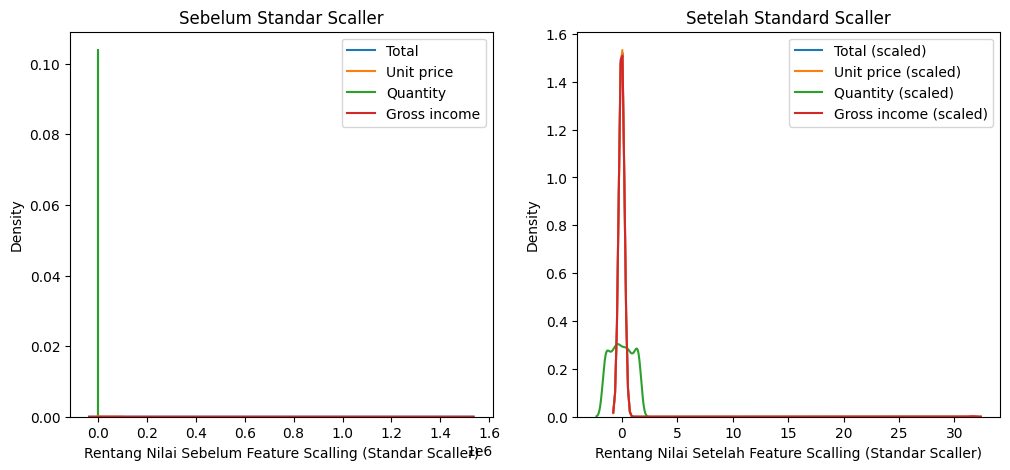

In [ ]:
# kita lihat distribusi dari variabel sebelum standar scaller dan setelah standar scaller
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler
ax1.set_title('Sebelum Standar Scaller')
sns.kdeplot(df_supermarket['Total'], ax=ax1, label='Total')
sns.kdeplot(df_supermarket['Unit price'], ax=ax1, label='Unit price')
sns.kdeplot(df_supermarket['Quantity'], ax=ax1, label='Quantity')
sns.kdeplot(df_supermarket['gross income'], ax=ax1, label='Gross income')

# Plot distribusi setelah Standar Scaler
ax2.set_title('Setelah Standard Scaller')
sns.kdeplot(df_supermarket['Total_stds'], ax=ax2, label='Total (scaled)')
sns.kdeplot(df_supermarket['Unit price_stds'], ax=ax2, label='Unit price (scaled)')
sns.kdeplot(df_supermarket['Quantity_stds'], ax=ax2, label='Quantity (scaled)')
sns.kdeplot(df_supermarket['gross income_stds'], ax=ax2, label='Gross income (scaled)')

# Set x-labels
ax1.set_xlabel('Rentang Nilai Sebelum Feature Scalling (Standar Scaller)')
ax2.set_xlabel('Rentang Nilai Setelah Feature Scalling (Standar Scaller)')

# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.show()

Berdasarkan kedua grafik diatas terlihat perbedaan sebelum dan sesudah Standard Scaller. Sebelum Standard Scaller setiap variabel memiliki rentang nilai yang sangat berbeda. Variabel Total, unit price dan gross income memiliki nilai yang jauh lebih besar dibandingkan Quantity, dimana distribusinya tampak menumpuk di dekat nilai nol pada grafik.

Setelah dilakukan Standard Scalling, seluruh variabel memiliki distribusi yang lebih terpusat di sekitar 0 dengan skala yang seragam. Hal ini menunjukkan bahwa proses standardisasi berhasil menormalkan perbedaan skala antar variabel sehingga setiap fitur dapat dibandingkan lebih seimbang.

Dengan skala yang dinormalisasi, variabel Total, Unit Price, Quantity, dan gross income tidak lagi didominasi oleh rentang nilai yang besar, sehingga lebih cocok digunakan dalam analisis lanjutan atau permodelan machine learning.

In [ ]:
# Checking result of standar scaller process
df_supermarket[['Total','Total_stds']].head()

,Total,Total_stds
0,548.9715,-0.026852
1,80.2200,-0.036746
2,340.5255,-0.031252
3,489.0480,-0.028117
4,634.3785,-0.025049


In [ ]:
# Checking statistical summary
# After standar scaller process the result has -> standar deviation (std) = 1 and mean = 0
df_supermarket[['Total','Total_stds']].describe()
# 9.103829e-17 = 9.103829 x 10^-17 = 0.00000000000000009103829 ~ 0
# 8.000000e+02 = 8 x 10^2 = 800 = 8 x e+2

,Total,Total_stds
count,1.001000e+03,1.001000e+03
mean,1.821146e+03,-1.774582e-18
std,4.740089e+04,1.000500e+00
min,1.067850e+01,-3.821388e-02
25%,1.250550e+02,-3.579971e-02
50%,2.540160e+02,-3.307771e-02
75%,4.723110e+02,-2.847011e-02
max,1.500000e+06,3.162235e+01


Scalling berhasil dilakukan dengan benar dengan nilai mean = 0 dan std =1 pada kolom Total_stds

#MinMax Scaller for Exploratory Data Analysis


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Kolom-kolom yang ingin dinormalisasi
columns_to_minmax = ['Total', 'Unit price', 'Quantity', 'gross income']

# Inisialisasi MinMaxScaler
minmax = MinMaxScaler()

In [ ]:
# Menerapkan normalisasi Min-Max
df_supermarket[['Total_minmax', 'Unit price_minmax', 'Quantity_minmax', 'gross income_minmax']] = minmax.fit_transform(df_supermarket[columns_to_minmax])

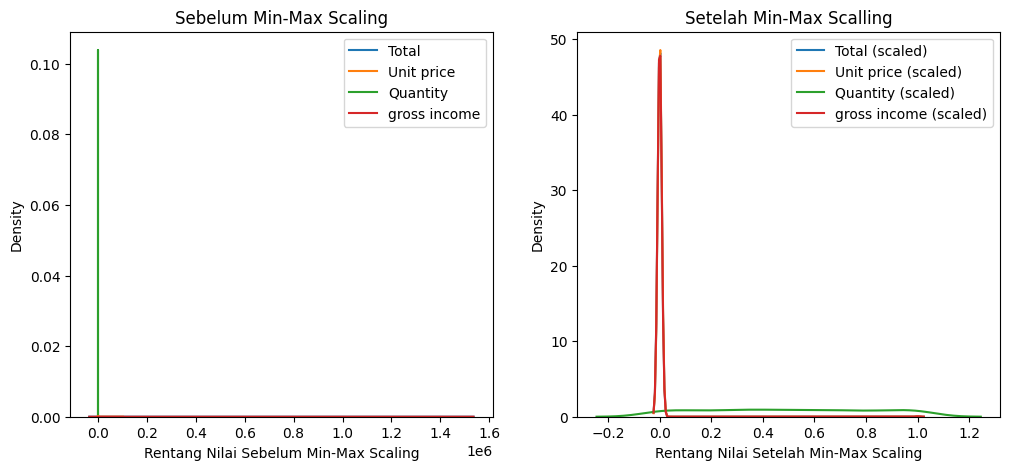

In [ ]:
# Plot distribusi sebelum dan sesudah Min-Max Scaling
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Min-Max Scaling
ax1.set_title('Sebelum Min-Max Scaling')
sns.kdeplot(df_supermarket['Total'], ax=ax1, label='Total')
sns.kdeplot(df_supermarket['Unit price'], ax=ax1, label='Unit price')
sns.kdeplot(df_supermarket['Quantity'], ax=ax1, label='Quantity')
sns.kdeplot(df_supermarket['gross income'], ax=ax1, label='gross income')
# sns.kdeplot(df_supermarket['Unit price'], ax=ax1, label='Unit price')

# Plot distribusi setelah Min-max Scalling
ax2.set_title('Setelah Min-Max Scalling')
sns.kdeplot(df_supermarket['Total_minmax'], ax=ax2, label='Total (scaled)')
sns.kdeplot(df_supermarket['Unit price_minmax'], ax=ax2, label='Unit price (scaled)')
sns.kdeplot(df_supermarket['Quantity_minmax'], ax=ax2, label='Quantity (scaled)')
sns.kdeplot(df_supermarket['gross income_minmax'], ax=ax2, label='gross income (scaled)')
# sns.kdeplot(df_supermarket['Unit price'], ax=ax1, label='Unit price')

# Set x-labels
ax1.set_xlabel('Rentang Nilai Sebelum Min-Max Scaling')
ax2.set_xlabel('Rentang Nilai Setelah Min-Max Scaling')

# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.show()

Berdasarkan grafik diatas, menunjukkan bahwa sebelum dilakukan minmax scaling setiap variabel memiliki nilai rentang yang berbeda. Pada variabel Total, gross income dan unit price memiliki nilai jauh lebih besar dibandingkan Quantity. Sehingga distribusi tampak terkonsentrasi pada area tertentu.

Setelah dilakukan Minmax scalling, seluruh nilai variabel dinormalisasikan pada rentang 0 hingga 1. Sehingga setiap fitur memiliki skala yang sama tanpa mengubah distribusi datas. variabel Total, Unit price, Quantity dan gross income dapat dibandingkan secara lebih seimbang dalam analisis.

Minmax scaller bertujuan untuk memperthankan distribusi asli data, sehingga hubungan antar variabel tetap terjaga meskipun skalanya telah dinormalisasi.

In [ ]:
# Checking result of standar scaller process
df_supermarket[['Unit price','Unit price_minmax']].head()

,Unit price,Unit price_minmax
0,74.69,0.000646
1,15.28,0.000052
2,46.33,0.000363
3,58.22,0.000481
4,86.31,0.000762


In [ ]:
# Checking statistical summary
# After standar scaller process the result has -> min (minimum) = 0 and max (maximum) = 1
df_supermarket[['Unit price','Unit price_minmax']].describe()

,Unit price,Unit price_minmax
count,1001.000000,1001.000000
mean,155.516613,0.001455
std,3159.049073,0.031594
min,10.080000,0.000000
25%,32.900000,0.000228
50%,55.390000,0.000453
75%,77.950000,0.000679
max,100000.000000,1.000000


Minmax berhasil dilakukan dengan nilai minimum = 0 dan maximum = 1

## Kesimpulan Analisis

1. Produk dengan penjualan tertinggi
Dapat dilihat dibagian agregasi dimana kolom product line dan quantity, terlihat bahwa beberapa kategori memiliki jumlah penjualan lebih tinggi dibandingkan kategori lainnya terutama untuk produk Food and Beverages.
2. Metode pembayaran yang paling sering    digunakan adalah Ewallet dan Cash dimana jumlah transaksinya lebih tinggi dibandingkan kategori lain.
3. Cabang dengan kontribusi penjualan terbesar ada pada cabang C.
4. Perbedaan pola pembelian berdasarkan Gender. terlihat bahwa pelanggan wanita cenderung memiliki jumah transaki paling sedikit.
5. Waktu transaki dengan aktivitas penjualan tertinggi yaitu siang, aktivitas pembelian cenderung lebih scalling periode tertentu.
6. Pengaruh proses scaling pada data numerik menjadikan data variabel memiliki skala yang lebih seragam sehingga memudahkan perbandingan antar variabel dalam analisis data maupun pemodelan machine learning.


## Final Business Insights

- Produk paling laku: Fashion accessories
- Waktu penjualan tertinggi: Sore
- Metode pembayaran paling sering: Cash
- Customer wanita berkontribusi lebih besar
- Cabang C memiliki performa terbaik

## Recommendation

- Fokus promosi di sore hari
- Target customer wanita
- Optimasi stok produk best seller